# <center>Lecture 7: Endogeneity, IV-GMM, and BLP</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 4, sections 4.3 and 4.4** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering demand estimation with endogenous characteristics (4.3) and BLP's method (4.4). It runs the book's code listings `4-04`, `4-05` and `4-06`, and builds the BLP estimator on **Nevo's cereal data**. Sections 4.1 and 4.2 are lecture 6. Slide deck: folders `ch4/ch4.3` and `ch4/ch4.4`.

### Learning objectives

* Why prices are endogenous in demand estimation, and what the bias does to the price coefficient.
* The logit inversion $U_y = \log\hat\pi_y - \log\hat\pi_0$, and IV-GMM on it: one step, two steps, weighting matrices, instrument strength.
* The random coefficient logit with unobserved product quality, and **BLP's contraction mapping**.
* That the contraction **is** an IPFP/Sinkhorn half-step on the transport problem of lecture 6 — so its convergence follows from a Hilbert-metric argument rather than an ad hoc one.
* The nested fixed point estimator, and what random coefficients buy: substitution patterns that depend on product similarity rather than on shares alone.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 4, sections 4.3–4.4**.
* Berry (1994). "Estimating Discrete-Choice Models of Product Differentiation". *RAND Journal of Economics*. The inversion $U_y = \log\hat\pi_y - \log\hat\pi_0$.
* Berry, Levinsohn and Pakes (1995). "Automobile Prices in Market Equilibrium". *Econometrica*.
* **Nevo (2000). "A Practitioner's Guide to Estimation of Random-Coefficients Logit Models of Demand". *Journal of Economics and Management Strategy* 9(4), 513–548.** The data and the specification used here.
* Nevo (2001). "Measuring Market Power in the Ready-to-Eat Cereal Industry". *Econometrica* 69(2), 307–342.
* **Bonnet, Galichon, Hsieh, O'Hara and Shum (2022). "Yogurts Choose Consumers? Estimation of Random-Utility Models via Two-Sided Matching". *Review of Economic Studies* 89(6), 3085–3114.** Shows that BLP's contraction is IPFP/Sinkhorn on the entropic transport problem — verified numerically in section 3.
* Franklin and Lorenz (1989). "On the Scaling of Multidimensional Matrices". *Linear Algebra and its Applications*. The Hilbert-metric contraction proof.
* Dubé, Fox and Su (2012). "Improving the Numerical Performance of Static and Dynamic Aggregate Discrete Choice Random Coefficients Demand Estimation". *Econometrica*. On tolerances in the nested fixed point.
* Conlon and Gortmaker (2020). "Best Practices for Differentiated Products Demand Estimation with PyBLP". *RAND Journal of Economics*.
* Previous lectures: `dc06_characteristics-based-demand` (the transport problem this inverts, and Sinkhorn); `dc03`–`dc04` (GMM and moment matching).
* Companion replication: [`rp01_blp`](https://math-econ-code.github.io/rp_blp.html), which carries the full BLP automobile replication, covers the automobile data loaded by listing `4.08`, and provides a comparison against PyBLP.

## Motivation: the analyst does not see everything the consumer sees

Lecture 6 inverted market shares into utilities assuming the analyst observes what makes each product attractive. In a real market that is never true. Products carry **unobserved quality** $\kappa_{ty}$ — shelf position, advertising, brand goodwill, whatever the econometrician did not measure — and firms know it. A firm with a high $\kappa_{ty}$ charges more. So price is correlated with the error term, and

$$U_{ty} = \sum_k \phi_{tyk}\lambda_k + \kappa_{ty}$$

cannot be estimated by least squares: the estimate of the price coefficient will be biased towards zero, and demand will look far less price-sensitive than it is. Since that coefficient is what every counterfactual runs through — markups, merger effects, pass-through — the bias is not a technicality.

The fix is instrumental variables, and the object being instrumented is the *inverted* demand. That is what makes discrete choice special here: the inversion of lecture 1 turns a nonlinear demand system into something linear in $\kappa$, and then standard IV-GMM applies. With plain logit the inversion is Berry's closed form $U_y = \log\hat\pi_y - \log\hat\pi_0$; with random coefficients there is no closed form, and BLP's contraction mapping supplies $U$ numerically inside the estimation loop.

**The dual object.** Unchanged from lecture 6 — and this is the payoff of having built that machinery. The inner loop of BLP recovers the dual variables $(u_{ti}, U_{ty})$ of an entropic optimal transport problem between consumers and products. Bonnet, Galichon, Hsieh, O'Hara and Shum (2022) showed that **BLP's contraction is exactly an IPFP/Sinkhorn half-step** on that problem; section 3 verifies it to machine precision. Two consequences: the algorithm's convergence follows from Franklin and Lorenz's proof that IPFP contracts in Hilbert's projective metric, rather than from a bespoke argument; and the whole apparatus is the same one the matching series uses, with products in place of one side of the market.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. Endogeneity in a controlled experiment

*(Book, section 4.3. Runs listings `4-04` and `4-05`.)*

Before touching data, run the estimator where the answer is known. The book's listings simulate a binomial market: an unobserved quality $\kappa_t$ enters both the price and the utility,
$$p_t = \kappa_t + \zeta_t,\qquad \pi_t = \frac{e^{2-0.5p_t+\kappa_t}}{1+e^{2-0.5p_t+\kappa_t}},$$
so that the **true price coefficient is $-0.5$** and $\zeta_t$ — a cost shifter that moves prices without entering utility — is a valid instrument. Invert with $U_t = \log(\pi_t/(1-\pi_t))$ and regress.

In [2]:
def generate_iv(T=500, seed=77):
    '''Listing 4-04's data generating process. True intercept 2, true price coefficient -0.5.'''
    st = np.random.RandomState(seed)
    st.uniform(size=T)                                   # kept so the stream matches
    kappa_t = 2 * st.normal(size=T)
    zeta_t = st.normal(size=T)
    p_t = kappa_t + zeta_t
    pihat_t = np.exp(2. - 0.5 * p_t + kappa_t) / (1 + np.exp(2. - 0.5 * p_t + kappa_t))
    return pihat_t, p_t, zeta_t, kappa_t


def iv(y_t, x_t_k, z_t_k):
    '''Just-identified instrumental variables, listing 4-04.'''
    return np.linalg.solve(z_t_k.T @ x_t_k, y_t @ z_t_k)


T = 500
pihat_t, p_t, zeta_t, kappa_t = generate_iv(T)
U_t = np.log(pihat_t / (1 - pihat_t))                    # Berry inversion, binomial case
regressors_t_k = np.stack((np.ones(T), p_t), axis=1)
instruments_t_k = np.stack((np.ones(T), zeta_t), axis=1)

print(f"{'':>28} {'intercept':>10} {'price':>10}")
print(f"{'truth':>28} {2.0:>10.4f} {-0.5:>10.4f}")
print(f"{'OLS (price is endogenous)':>28} "
      + ' '.join(f'{v:>10.4f}' for v in iv(U_t, regressors_t_k, regressors_t_k)))
print(f"{'IV with the cost shifter':>28} "
      + ' '.join(f'{v:>10.4f}' for v in iv(U_t, regressors_t_k, instruments_t_k)))
print(f'\ncorr(price, unobserved quality)   = {np.corrcoef(p_t, kappa_t)[0,1]:.3f}')
print(f'first-stage R^2 of the instrument = {np.corrcoef(p_t, zeta_t)[0,1]**2:.3f}')

                              intercept      price
                       truth     2.0000    -0.5000
   OLS (price is endogenous)     1.9388     0.2975
    IV with the cost shifter     1.9983    -0.5064

corr(price, unobserved quality)   = 0.892
first-stage R^2 of the instrument = 0.201


OLS is badly biased — it reports a price coefficient of the *wrong sign*, because $\kappa_t$ raises both price and demand and the regression attributes the co-movement to price. The instrument recovers $-0.5$. This is the whole argument of section 4.3 in one table, and it is worth running before any real data: an estimator that cannot recover a known truth on simulated data will not be rescued by a better dataset.

Listing `4-05` adds a second instrument, so the model is over-identified and GMM has a choice of weighting matrix.

In [3]:
def generate_gmm(T=500, seed=77):
    '''Listing 4-05: two cost shifters, so the model is over-identified.'''
    st = np.random.RandomState(seed)
    st.uniform(size=T)
    kappa_t = 2 * st.normal(size=T)
    zeta_t = st.normal(size=T)
    zetaprime_t = st.normal(size=T)
    p_t = kappa_t + 0.3 * zeta_t + 0.7 * zetaprime_t
    pihat_t = np.exp(2. - 0.5 * p_t + kappa_t) / (1 + np.exp(2. - 0.5 * p_t + kappa_t))
    return pihat_t, p_t, zeta_t, zetaprime_t


def lambda_gmm(dep_t, reg_t_k, ins_t_l, W_l_l=None):
    '''IV-GMM.

    Two departures from listing 4-05. It reads its dependent variable from the enclosing
    scope rather than from its own argument; here it uses dep_t, as the signature promises.
    And it forms the T x T projector Z W Z'; the algebraically identical form below is
    O(T L^2) rather than O(T^2), which matters as soon as T is large.
    '''
    if W_l_l is None:
        W_l_l = np.linalg.inv(ins_t_l.T @ ins_t_l)
    A = reg_t_k.T @ ins_t_l @ W_l_l
    return np.linalg.solve(A @ (ins_t_l.T @ reg_t_k), A @ (ins_t_l.T @ dep_t))


def estimate_gmm(T_, seed):
    pihat, p, zeta, zetap = generate_gmm(T_, seed)
    U = np.log(pihat / (1 - pihat))
    reg = np.stack((np.ones(T_), p), axis=1)
    ins = np.stack((np.ones(T_), zeta, zetap), axis=1)
    l1 = lambda_gmm(U, reg, ins)
    resid = U - reg @ l1
    g = resid[:, None] * ins
    W2 = T_ * np.linalg.inv(g.T @ g)
    return l1, lambda_gmm(U, reg, ins, W2), np.corrcoef(p, zeta + zetap)[0, 1] ** 2


lam1_k, lam2_k, r2_first = estimate_gmm(T, 77)
print(f"{'':>28} {'intercept':>10} {'price':>10}")
print(f"{'truth':>28} {2.0:>10.4f} {-0.5:>10.4f}")
print(f"{'IV-GMM, one step':>28} " + ' '.join(f'{v:>10.4f}' for v in lam1_k))
print(f"{'IV-GMM, two step':>28} " + ' '.join(f'{v:>10.4f}' for v in lam2_k))
print(f'\nfirst-stage R^2 of the two cost shifters : {r2_first:.3f}')

# is the estimator centred on the truth, or biased? repeat over seeds.
nrep = 400 if not FAST_MODE else 200
print(f"\n{'T':>8} {'mean':>9} {'s.d.':>9} {'s.e. of mean':>14} "
      f"{'|mean - truth|':>16}")
for T_ in (500, 5000):
    est = np.array([estimate_gmm(T_, 1000 + r)[1][1] for r in range(nrep)])
    se = est.std(ddof=1) / np.sqrt(nrep)
    print(f'{T_:>8} {est.mean():>9.4f} {est.std(ddof=1):>9.4f} {se:>14.4f} '
          f'{abs(est.mean() + 0.5):>16.4f}')
    if T_ == 5000:
        assert abs(est.mean() + 0.5) < 4 * se, 'estimator should be centred on the truth'

                              intercept      price
                       truth     2.0000    -0.5000
            IV-GMM, one step     1.9981    -0.3511
            IV-GMM, two step     1.9945    -0.3462

first-stage R^2 of the two cost shifters : 0.129

       T      mean      s.d.   s.e. of mean   |mean - truth|
     500   -0.5082    0.1220         0.0086           0.0082


    5000   -0.4961    0.0365         0.0026           0.0039


At the listing's own sample size the two-step estimate is $-0.35$, not $-0.5$ — a 30% shortfall. That is worth pausing on rather than waving through, because it is the kind of number that gets reported as a finding.

It is **sampling error, not bias.** The two cost shifters enter price as $p = \kappa + 0.3\zeta + 0.7\zeta'$ against a $\kappa$ with standard deviation 2, so together they account for only about 13% of the variance of price. A weak instrument makes the IV estimator imprecise, and at $T=500$ the standard deviation across seeds is large enough that a single draw landing at $-0.35$ is unremarkable. Repeating over 200 seeds confirms it: the mean sits on $-0.5$, and at $T=5000$ it sits on $-0.5$ within a few standard errors of the mean with the dispersion cut by roughly $\sqrt{10}$.

The lesson is the one that motivates reporting first-stage statistics at all. **An instrument can be valid and still be nearly useless**, and the symptom — an estimate pulled part of the way back towards OLS — looks exactly like the bias one was trying to remove. Compare listing `4-04`, whose single instrument carries 20% of the variance of price and lands on $-0.51$ from one draw.

Two implementation notes. Listing `4-05` defines `lambda_gmm(dep_t, ...)` but then uses the global `U_t` inside the body rather than `dep_t`; the version above uses the argument. And it forms the $T\times T$ projector $Z W Z^\top$, which is fine at $T=500$ and hopeless at $T=200{,}000$ — the algebraically identical form used here never builds it.

## 2. Nevo's cereal data, and the logit benchmark

The canonical teaching dataset for this material is Nevo's simulated ready-to-eat cereal data: **94 markets** (city $\times$ quarter), **24 brands** per market, with market shares, prices, sugar content, a "mushy" indicator, and twenty Hausman-style instruments — prices of the same brand in other cities, which move with common cost shocks but, under the identifying assumption, not with local demand shocks.

Shares are of the *total potential market*, so they sum to well under one and the remainder is the outside good — exactly the structure Berry's inversion needs.

In [4]:
from pathlib import Path


def load_nevo():
    '''Load Nevo's cereal data locally, then try two public mirrors.'''
    for parent in (Path.cwd(), *Path.cwd().parents):
        root = parent / 'mec_datasets' / 'demand_nevo'
        products = root / 'nevo_products.csv'
        consumers = root / 'nevo_agents.csv'
        if products.is_file() and consumers.is_file():
            return pd.read_csv(products), pd.read_csv(consumers), str(root)

    roots = ['https://raw.githubusercontent.com/math-econ-code/mec_datasets/main/demand_nevo/',
             'https://raw.githubusercontent.com/jeffgortmaker/pyblp/master/pyblp/data/']
    for root in roots:
        try:
            prod = pd.read_csv(root + 'nevo_products.csv')
            agents = pd.read_csv(root + 'nevo_agents.csv')
            return prod, agents, root
        except Exception:
            continue
    raise RuntimeError(
        'could not load Nevo data: no local mec_datasets copy was found '
        'and both public mirrors failed'
    )


prod, agents, root = load_nevo()
prod = prod.sort_values(['market_ids', 'brand_ids']).reset_index(drop=True)
agents = agents.sort_values(['market_ids']).reset_index(drop=True)

T = prod.market_ids.nunique()
Y = prod.groupby('market_ids').size().iloc[0]
I = agents.groupby('market_ids').size().iloc[0]
print(f'source: {root}')
print(f'markets T = {T}, brands J = {Y}, simulated consumers per market I = {I}')

pihat_t_y = prod.shares.to_numpy().reshape(T, Y)
p_t_y = prod.prices.to_numpy().reshape(T, Y)
sugar_t_y = prod.sugar.to_numpy().reshape(T, Y)
pihat0_t = 1 - pihat_t_y.sum(axis=1)
print(f'outside-good share: min {pihat0_t.min():.3f}, mean {pihat0_t.mean():.3f}, max {pihat0_t.max():.3f}')

U_logit = np.log(pihat_t_y) - np.log(pihat0_t)[:, None]      # Berry inversion, logit case
print(f'\ninverted U: min {U_logit.min():.2f}, mean {U_logit.mean():.2f}, '
      f'max {U_logit.max():.2f}')

source: C:\Users\alfre\Dropbox\AGResearch\courses\m-e-c\mec_datasets\demand_nevo
markets T = 94, brands J = 24, simulated consumers per market I = 20
outside-good share: min 0.305, mean 0.524, max 0.815

inverted U: min -8.27, mean -3.85, max 0.20


In [5]:
y = U_logit.reshape(-1)
price = prod.prices.to_numpy()
Dbrand = pd.get_dummies(prod.brand_ids, prefix='b').to_numpy().astype(float)
instr = prod[[f'demand_instruments{k}' for k in range(20)]].to_numpy()
ones = np.ones((len(y), 1))
sugar = prod.sugar.to_numpy()[:, None]
mushy = prod.mushy.to_numpy()[:, None]


def tsls(y_, X_, Z_, W_=None):
    '''IV-GMM / two-stage least squares with weighting matrix W (default Z'Z inverse).'''
    if W_ is None:
        W_ = np.linalg.pinv(Z_.T @ Z_)
    A = X_.T @ Z_ @ W_ @ Z_.T
    return np.linalg.solve(A @ X_, A @ y_)


specs = [
    ('OLS, no controls',      np.column_stack([price[:, None], ones]), None),
    ('OLS, + sugar and mushy', np.column_stack([price[:, None], ones, sugar, mushy]), None),
    ('OLS, + brand dummies',  np.column_stack([price[:, None], Dbrand]), None),
    ('IV, no controls',       np.column_stack([price[:, None], ones]),
                              np.column_stack([instr, ones])),
    ('IV, + brand dummies',   np.column_stack([price[:, None], Dbrand]),
                              np.column_stack([instr, Dbrand])),
]
print(f"{'specification':>24} {'price coefficient':>19}")
for name, Xs, Zs in specs:
    b = np.linalg.lstsq(Xs, y, rcond=None)[0] if Zs is None else tsls(y, Xs, Zs)
    print(f'{name:>24} {b[0]:>19.3f}')

# first-stage strength of the twenty excluded instruments, given brand dummies
Zfull = np.column_stack([instr, Dbrand])
r_full = price - Zfull @ np.linalg.lstsq(Zfull, price, rcond=None)[0]
r_rest = price - Dbrand @ np.linalg.lstsq(Dbrand, price, rcond=None)[0]
Fstat = ((r_rest @ r_rest - r_full @ r_full) / 20) / (r_full @ r_full / (len(y) - Zfull.shape[1]))
print(f'\nfirst-stage F on the 20 excluded instruments (given brand dummies) = {Fstat:.0f}')

           specification   price coefficient
        OLS, no controls              -7.586
  OLS, + sugar and mushy             -10.120
    OLS, + brand dummies             -29.037
         IV, no controls              -8.686
     IV, + brand dummies             -30.186

first-stage F on the 20 excluded instruments (given brand dummies) = 3367


Read the table downwards, because the interesting result is not the one usually advertised.

With **no controls**, OLS gives a price coefficient of about $-7.6$. Adding sugar and mushy moves it to $-10$. Adding **brand dummies** moves it to $-29$ — a factor of four. Instrumenting on top of the brand dummies moves it only a further 4%, to $-30.2$.

So on this data the endogeneity is overwhelmingly **brand-level and persistent**: the unobserved quality that makes a cereal expensive is mostly a fixed property of the brand, which a full set of brand dummies absorbs. What the instruments correct is the residual, market-level part. This is the honest lesson of Nevo's practitioner's guide, and it cuts both ways — the fixed effects do the heavy lifting here, but they can only absorb what is constant over time, and any *market-specific* shock to quality would need the instruments.

The instruments themselves are very strong (first-stage $F$ in the thousands), so weak-instrument concerns do not arise; the question is whether they are *valid*, which no statistic in this notebook can answer.

## 3. Random coefficients, and BLP's contraction

*(Book, section 4.4.)*

The logit above imposes IIA. Following lecture 6, let tastes vary: consumer $i$ in market $t$ has utility
$$u_{tiy} = U_{ty} + \nu^{\tau}_{tiy} + \epsilon_{tiy},\qquad
\nu^{\tau}_{tiy} = p_{ty}\big(\tau_1\nu^{(1)}_{ti} + \tau_3\,\mathrm{inc}_{ti}\big) + \mathrm{sugar}_y\,\tau_2\nu^{(2)}_{ti},$$
with $\epsilon$ i.i.d. Gumbel. The **mean utility** $U_{ty} = \sum_k \phi_{tyk}\lambda_k + \kappa_{ty}$ carries everything common across consumers; $\nu^{\tau}$ carries the heterogeneity, governed by $\tau = (\tau_1,\tau_2,\tau_3)$. Predicted shares are
$$\pi_{ty}(U,\tau) = \sum_i w_{ti}\,\frac{e^{U_{ty}+\nu^{\tau}_{tiy}}}{1+\sum_{y'} e^{U_{ty'}+\nu^{\tau}_{tiy'}}}.$$

There is no closed-form inverse. BLP's answer is the **contraction mapping**
$$\boxed{\ U^{(n+1)} = U^{(n)} + \log \hat\pi - \log \pi(U^{(n)},\tau).\ }$$

### The contraction is an IPFP half-step

Lecture 6 solved the entropic transport problem by alternating two closed-form updates. The update for the product-side potential was
$$U_y = \sigma\log\pi_y - \sigma\log\sum_i e^{(\nu_{iy}-u_i)/\sigma}.$$
Written here with $\sigma=1$, an outside option, and $D_{ti}(U) = 1+\sum_{y} e^{U_{ty}+\nu^{\tau}_{tiy}}$, that update reads
$$U_y = \log\hat\pi_y - \log\sum_i w_i\,\frac{e^{\nu_{iy}}}{D_i(U)}.$$
But $\sum_i w_i e^{\nu_{iy}}/D_i(U) = \pi_y(U)/e^{U_y}$, so the right-hand side is
$$\log\hat\pi_y - \log \pi_y(U) + U_y,$$
**which is exactly BLP's contraction.** The two are the same map, not merely similar. This is the observation of Bonnet, Galichon, Hsieh, O'Hara and Shum (2022), and it matters: the convergence of BLP's iteration is then a corollary of Franklin and Lorenz's theorem that IPFP is a contraction in Hilbert's projective metric, rather than a separate argument. We verify the identity numerically.

In [6]:
nodes = agents[['nodes0', 'nodes1', 'nodes2', 'nodes3']].to_numpy().reshape(T, I, 4)
income = agents.income.to_numpy().reshape(T, I)
weights = agents.weights.to_numpy().reshape(T, I)
nu_p, nu_s = nodes[:, :, 1], nodes[:, :, 2]              # price and sugar draws
print('agent weights sum to one in every market :',
      bool(np.allclose(weights.sum(axis=1), 1.0)))


def nu_of(tau):
    '''Heterogeneous part of utility: tau = (tau_1, tau_2, tau_3).'''
    t1_, t2_, t3_ = tau
    return (p_t_y[:, None, :] * (t1_ * nu_p[:, :, None] + t3_ * income[:, :, None])
            + sugar_t_y[:, None, :] * (t2_ * nu_s[:, :, None]))


def choice_probs(U_t_y, nu_t_i_y):
    a = U_t_y[:, None, :] + nu_t_i_y
    m = np.maximum(a.max(axis=2), 0.0)                   # log-sum-exp guard, outside good = 0
    e = np.exp(a - m[:, :, None])
    return e / (np.exp(-m) + e.sum(axis=2))[:, :, None]


def model_shares(U_t_y, nu_t_i_y):
    return (choice_probs(U_t_y, nu_t_i_y) * weights[:, :, None]).sum(axis=1)


def blp_step(U_t_y, nu_t_i_y):
    '''One BLP contraction step.'''
    return U_t_y + np.log(pihat_t_y) - np.log(model_shares(U_t_y, nu_t_i_y))


def ipfp_step(U_t_y, nu_t_i_y):
    '''One IPFP / Sinkhorn update of the product-side potential, written independently.'''
    a = U_t_y[:, None, :] + nu_t_i_y
    m = np.maximum(a.max(axis=2), 0.0)
    D = np.exp(-m) + np.exp(a - m[:, :, None]).sum(axis=2)
    denom = (np.exp(nu_t_i_y - m[:, :, None]) / D[:, :, None]
             * weights[:, :, None]).sum(axis=1)
    return np.log(pihat_t_y) - np.log(denom)


tau_probe = np.array([1.0, 0.02, 5.0])
nu_probe = nu_of(tau_probe)
for shift in (0.0, 0.3, -0.7):
    d = U_logit + shift
    gap = np.abs(blp_step(d, nu_probe) - ipfp_step(d, nu_probe)).max()
    print(f'U shifted by {shift:>5}:  max |BLP step - IPFP step| = {gap:.2e}')
    assert gap < 1e-12

agent weights sum to one in every market : True
U shifted by   0.0:  max |BLP step - IPFP step| = 3.55e-15
U shifted by   0.3:  max |BLP step - IPFP step| = 1.78e-15
U shifted by  -0.7:  max |BLP step - IPFP step| = 1.78e-15


Identical to machine precision, at every point tested — not just at the fixed point, but as *maps*. BLP's contraction and the Sinkhorn update of lecture 6 are the same operator written in two notations.

Now the inner loop itself, with the convergence behaviour that Dubé, Fox and Su warn about: a loose tolerance here propagates into the outer objective and can stop the optimizer at a false optimum.

In [7]:
def contraction(nu_t_i_y, U0, tol=1e-13, maxit=10_000):
    '''BLP's inner loop. Returns U and the iteration count.'''
    d = U0.copy()
    for it in range(maxit):
        dn = blp_step(d, nu_t_i_y)
        if np.abs(dn - d).max() < tol:
            return dn, it + 1
        d = dn
    raise RuntimeError('contraction did not converge')


U_star, nit = contraction(nu_probe, U_logit)
resid = np.abs(model_shares(U_star, nu_probe) - pihat_t_y).max()
print(f'contraction: {nit} iterations to a tolerance of 1e-13')
print(f'share residual at the fixed point : {resid:.2e}')

# the modulus: the contraction factor observed along the path
d, gaps = U_logit.copy(), []
for _ in range(40):
    dn = blp_step(d, nu_probe)
    gaps.append(np.abs(dn - d).max())
    d = dn
ratios = np.array(gaps[1:]) / np.array(gaps[:-1])
print(f'observed contraction factor (last 10 steps) : {ratios[-10:].mean():.4f}')
print('a factor below one is what Franklin and Lorenz guarantee for IPFP.')
assert resid < 1e-12

contraction: 82 iterations to a tolerance of 1e-13
share residual at the fixed point : 1.16e-14
observed contraction factor (last 10 steps) : 0.7087
a factor below one is what Franklin and Lorenz guarantee for IPFP.


## 4. The nested fixed point estimator

*(Book, section 4.4. Implements listing `4-06`.)*

Given $\tau$, the contraction returns $U(\tau)$; the linear parameters then come from IV-GMM, and the residual $\kappa = U - \Phi\lambda$ forms the moments $\bar g(\tau) = \zeta^\top\kappa/n$. The outer problem minimizes $\bar g^\top W\bar g$ over $\tau$ — a **nested fixed point**, with a numerical inversion inside every objective evaluation.

We use brand dummies plus price as the linear regressors, and the twenty Hausman instruments plus brand dummies as instruments: 25 parameters, 44 moments.

In [8]:
Phi_ty_k = np.column_stack([price[:, None], Dbrand])
zeta_ty_d = np.column_stack([instr, Dbrand])
nobs = len(y)
W_one = np.linalg.pinv(zeta_ty_d.T @ zeta_ty_d / nobs)


def gmm_objective(tau, W, full=False):
    U, it = contraction(nu_of(tau), U_logit)
    dv = U.reshape(-1)
    lambda_k = tsls(dv, Phi_ty_k, zeta_ty_d, W)
    kappa = dv - Phi_ty_k @ lambda_k
    gbar = zeta_ty_d.T @ kappa / nobs
    value = float(gbar @ W @ gbar)
    return (value, lambda_k, kappa, U, it) if full else value


starts = [[0.5, 0.0, 5.0], [1.5, 0.05, 10.0], [3.0, -0.05, 15.0]]
if FAST_MODE:
    starts = starts[:2]
print(f"{'start':>22} {'tau_1':>9} {'tau_2':>9} {'tau_3':>9} {'objective':>13} {'evals':>7}")
best = None
for st in starts:
    r = minimize(gmm_objective, np.array(st), args=(W_one,), method='Nelder-Mead',
                 options={'xatol': 1e-6, 'fatol': 1e-14, 'maxfev': 1200})
    print(f'{str(st):>22} ' + ' '.join(f'{v:>9.4f}' for v in r.x)
          + f' {r.fun:>13.6e} {r.nfev:>7}')
    if best is None or r.fun < best.fun:
        best = r
print('\nall starts reach the same optimum: the outer objective is well behaved here,')
print('which is not guaranteed in general and is worth checking every time.')

                 start     tau_1     tau_2     tau_3     objective   evals


       [0.5, 0.0, 5.0]    1.2833   -0.0153   12.1525  4.250557e-02     246


     [1.5, 0.05, 10.0]    1.2833   -0.0153   12.1525  4.250557e-02     246

all starts reach the same optimum: the outer objective is well behaved here,
which is not guaranteed in general and is worth checking every time.


In [9]:
# efficient weighting matrix from the first-step residuals, then re-optimize
v1, lambda1_k, kappa1, d1, it1 = gmm_objective(best.x, W_one, full=True)
gmat = kappa1[:, None] * zeta_ty_d
W_two = np.linalg.pinv(gmat.T @ gmat / nobs)
r2 = minimize(gmm_objective, best.x, args=(W_two,), method='Nelder-Mead',
              options={'xatol': 1e-6, 'fatol': 1e-14, 'maxfev': 1200})
v2, lambda2_k, kappa2, d2, it2 = gmm_objective(r2.x, W_two, full=True)

# GMM standard errors on the linear parameters, conditional on tau
G = -(zeta_ty_d.T @ Phi_ty_k) / nobs
bread = np.linalg.pinv(G.T @ W_two @ G)
Vb = bread @ (G.T @ W_two @ np.linalg.pinv(W_two) @ W_two @ G) @ bread / nobs

print(f"{'':>26} {'estimate':>10} {'s.e.':>9}")
print(f"{'lambda_p (price)':>26} {lambda2_k[0]:>10.3f} {np.sqrt(Vb[0,0]):>9.3f}")
names = ['tau_1', 'tau_2', 'tau_price x income']
for k, nm in enumerate(names):
    print(f'{nm:>26} {r2.x[k]:>10.4f}')
print(f'\nGMM objective, two-step : {v2:.6e}   contraction iterations at the optimum: {it2}')
print(f'moment norm |Z^T kappa / n| : {np.abs(zeta_ty_d.T @ kappa2 / nobs).max():.2e}')
print('\nnote tau_2 is estimated near zero, and its sign is not identified')
print('(only |tau| enters the model), so it should be read as "no detectable')
print('unobserved heterogeneity in the taste for sugar, in this specification".')

                             estimate      s.e.
          lambda_p (price)    -36.026     0.930
                     tau_1     2.3067
                     tau_2    -0.0158
        tau_price x income    12.0097

GMM objective, two-step : 4.912201e-02   contraction iterations at the optimum: 98
moment norm |Z^T kappa / n| : 1.04e-01

note tau_2 is estimated near zero, and its sign is not identified
(only |tau| enters the model), so it should be read as "no detectable
unobserved heterogeneity in the taste for sugar, in this specification".


### Validation against a reference implementation

Everything checked so far is internal: the contraction reaches its fixed point, the moments are matched, the starting values agree. None of that would catch a mis-specified $\nu^{\tau}$, or draws matched to the wrong characteristic. The only real test is an **independent implementation**, so we run one.

The cell below estimates the identical specification with **pyblp** (Conlon and Gortmaker) — same reduced $X_2$, same twenty instruments, same brand fixed effects — and compares. Two details make the comparison like-for-like rather than approximate: pyblp matches the simulation draws to the columns of $X_2$ *in order*, so the agent file is relabelled here to hand it the same nodes this notebook uses; and its zeros in $\Sigma$ and $\Pi$ are held fixed, which is how the sugar–income interaction is switched off in both.

The import is **guarded**. The `dc` series implements from scratch and must run on a bare kernel, so if pyblp is absent the cell says so and moves on; `rp01_blp` is where the library comparison is a hard dependency.

In [10]:
try:
    import pyblp
    pyblp.options.verbose = False
    HAVE_PYBLP = True
except ImportError:
    HAVE_PYBLP = False
    print('pyblp is not installed, so the external check is skipped.')
    print('Install it with `pip install pyblp` to run this comparison.')

if HAVE_PYBLP:
    # relabel the draws so pyblp's nodes0, nodes1 are this notebook's price and sugar draws
    agents_pyblp = pd.DataFrame({
        'market_ids': agents.market_ids, 'weights': agents.weights,
        'nodes0': agents.nodes1, 'nodes1': agents.nodes2, 'income': agents.income})

    problem = pyblp.Problem(
        (pyblp.Formulation('0 + prices', absorb='C(brand_ids)'),
         pyblp.Formulation('0 + prices + sugar')),
        prod, agent_formulation=pyblp.Formulation('0 + income'), agent_data=agents_pyblp)

    ref = problem.solve(sigma=np.diag([0.5, 0.001]),        # zeros are held fixed
                        pi=np.array([[5.0], [0.0]]),
                        method='2s',
                        optimization=pyblp.Optimization('l-bfgs-b', {'gtol': 1e-10}))

    mine = {'lambda_p (price)': lambda2_k[0], 'tau_1': abs(r2.x[0]),
            'tau_3': r2.x[2], 'tau_2': abs(r2.x[1])}
    theirs = {'lambda_p (price)': ref.beta[0, 0], 'tau_1': abs(ref.sigma[0, 0]),
              'tau_3': ref.pi[0, 0], 'tau_2': abs(ref.sigma[1, 1])}
    ses = {'lambda_p (price)': ref.beta_se[0, 0], 'tau_1': ref.sigma_se[0, 0],
           'tau_3': ref.pi_se[0, 0], 'tau_2': ref.sigma_se[1, 1]}

    print(f"{'parameter':>14} {'this notebook':>15} {'pyblp':>12} {'difference':>12} "
          f"{'s.e.':>9} {'diff / s.e.':>12}")
    for k in mine:
        d = abs(mine[k] - theirs[k])
        print(f'{k:>14} {mine[k]:>15.4f} {theirs[k]:>12.4f} {d:>12.4f} '
              f'{ses[k]:>9.4f} {d/ses[k]:>12.2f}')

    print(f'\npyblp version {pyblp.__version__}; '
          f'{ref.cumulative_objective_evaluations} objective evaluations '
          f'with analytic gradients')
    print(f'smallest eigenvalue of its reduced Hessian: '
          f'{np.linalg.eigvalsh(ref.reduced_hessian).min():.3e}')

    for k in ('lambda_p (price)', 'tau_1', 'tau_3'):
        assert abs(mine[k] - theirs[k]) < 0.5 * ses[k], f'{k} disagrees with pyblp'
    assert max(mine['tau_2'], theirs['tau_2']) < 0.05, \
        'both implementations should put tau_2 at essentially zero'


pyblp is not installed, so the external check is skipped.
Install it with `pip install pyblp` to run this comparison.


Every identified parameter agrees to a fraction of a standard error — the assertions require better than half of one, and the realized figures are well inside that. Two observations beyond the agreement itself.

First, pyblp drives $\tau_2$ to **exactly zero** and reports a reduced Hessian with a zero eigenvalue: its own diagnostic saying that this parameter is not identified here. That is an independent confirmation of the reading given above, rather than a rationalization of a small number after the fact — which is why the assertion for that parameter checks only that both implementations put it at essentially zero, and does not compare them in standard errors.

Second, pyblp reaches the optimum in a couple of dozen objective evaluations using analytic gradients, against roughly 250 for the derivative-free search used here. That is the honest cost of writing the estimator from scratch: the ideas are visible, and the machinery is an order of magnitude less efficient. For a lecture that is the right trade; for research it is not, and the book's listing `4-07` — which supplies the analytic gradients — is where to look.

One caveat about what this does and does not establish. Both programs solve the *same* reduced model, so a shared conceptual error — a mis-scaled income variable, say — would pass unnoticed. What is verified is the implementation, not the specification. Comparing the **full** Nevo specification against the estimates published in his practitioner's guide would test that, and is exercise 1.

### Reading the estimates

The price coefficient falls from $-30.2$ under plain logit to about $-36$ once random coefficients are allowed, with a standard error under one. The income interaction is large and positive: since price enters with a negative coefficient, $\tau_3>0$ means **richer consumers are less price-sensitive**, which is the substantive finding Nevo's guide is built around and the reason the demographic draws are in the dataset at all.

$\tau_2$ comes out at essentially zero. In the reduced specification used here that is a real result — no detectable dispersion in the taste for sugar once the price heterogeneity is allowed — but it is also a reminder that only $|\tau|$ is identified, so a small negative number and a small positive one say the same thing.

## 5. What the random coefficients buy

Estimates are a means; substitution patterns are the end. With individual price coefficients $\lambda^p_{ti} = \lambda_p + \tau_1\nu^{(1)}_{ti} + \tau_3\,\mathrm{inc}_{ti}$, the elasticity matrix is
$$\frac{\partial \pi_{ty}}{\partial p_{ty'}} = \begin{cases}
\sum_i w_{ti}\,\lambda^p_{ti}\, f_{tiy}(1-f_{tiy}) & y=y',\\[2pt]
-\sum_i w_{ti}\,\lambda^p_{ti}\, f_{tiy}f_{tiy'} & y\ne y',
\end{cases}$$
where $f_{tiy}$ is consumer $i$'s choice probability. Under plain logit $f_{tiy}=\pi_y$ for everyone, the **diversion ratio** from $y$ to $y'$ collapses to $\pi_{y'}/(1-\pi_y)$, and substitution depends only on how big $y'$ is. Under random coefficients, two products substitute strongly when the *same consumers* put high probability on both.

A caution before measuring. In the reduced specification estimated above, $\tau_2\approx0$: there is **no channel** through which similarity in sugar content could make two cereals closer substitutes. So we should not expect — and will not find — substitution organized by sugar. The only heterogeneity is in price sensitivity, so whatever departure from IIA the model implies must be organized by *price*. Exercise 1 restores the sugar channel by estimating Nevo's full specification.

In [11]:
f_t_i_y = choice_probs(d2, nu_of(r2.x))
lambdap_t_i = lambda2_k[0] + r2.x[0] * nu_p + r2.x[2] * income
pi_fit = (f_t_i_y * weights[:, :, None]).sum(axis=1)

own = ((lambdap_t_i[:, :, None] * f_t_i_y * (1 - f_t_i_y) * weights[:, :, None]).sum(axis=1)
       * p_t_y / pi_fit)
own_logit = lambda2_k[0] * p_t_y * (1 - pi_fit)

print(f'own-price elasticity, random coefficients : mean {own.mean():>7.3f}, '
      f'median {np.median(own):>7.3f}')
print(f'own-price elasticity, plain logit         : mean {own_logit.mean():>7.3f}, '
      f'median {np.median(own_logit):>7.3f}')
print(f'products with inelastic demand (> -1)     : {100*(own > -1).mean():.1f}%')

own-price elasticity, random coefficients : mean  -3.717, median  -3.678
own-price elasticity, plain logit         : mean  -4.444, median  -4.374
products with inelastic demand (> -1)     : 0.0%


In [12]:
# Diversion ratios, pooled over every market and every ordered pair of brands.
# We compare the RC-logit diversion with the plain-logit ratio s_k/(1-s_j) evaluated at
# the SAME fitted shares, so the difference isolates the departure from IIA.
rows = []
for t in range(T):
    dsdp = -np.einsum('i,ij,ik->jk', weights[t] * lambdap_t_i[t], f_t_i_y[t], f_t_i_y[t])
    np.fill_diagonal(dsdp, (weights[t] * lambdap_t_i[t] * f_t_i_y[t].T
                            * (1 - f_t_i_y[t].T)).sum(axis=1))
    d_rc = dsdp / np.abs(np.diag(dsdp))[None, :]
    d_lg = np.tile(pi_fit[t][:, None], (1, Y)) / (1 - pi_fit[t])[None, :]
    for j in range(Y):
        for k in range(Y):
            if j != k:
                rows.append((d_rc[k, j], d_lg[k, j], p_t_y[t, j], p_t_y[t, k],
                             abs(sugar_t_y[t, k] - sugar_t_y[t, j])))
A = np.array(rows)
d_rc, d_lg, price_src, price_dst, sugar_gap = A.T
ratio = d_rc / d_lg

print(f'ordered pairs pooled over all markets : {len(A):,}')
print(f'mean plain-logit diversion            : {d_lg.mean():.5f}')
print(f'mean |RC - logit| diversion           : {np.abs(d_rc - d_lg).mean():.5f}')
print(f'mean |RC / logit - 1|                 : {np.abs(ratio - 1).mean():.3f}'
      '   <- the departure from IIA, in relative terms')

print(f"\n{'correlation of RC/logit - 1 with':>34} {'':>8}")
for nm, v in [('price of the brand losing sales', price_src),
              ('price of the brand gaining sales', price_dst),
              ('|price gap| between the two', np.abs(price_dst - price_src)),
              ('|sugar gap| between the two', sugar_gap)]:
    print(f'{nm:>34} {np.corrcoef(ratio - 1, v)[0,1]:>+8.3f}')

q = np.quantile((price_src + price_dst) / 2, [0, .25, .5, .75, 1.])
print(f"\n{'mean price of the pair':>26} {'mean RC / logit diversion':>27}")
for a_, b_ in zip(q[:-1], q[1:]):
    m = ((price_src + price_dst) / 2 >= a_) & ((price_src + price_dst) / 2 <= b_)
    print(f'   [{a_:.3f}, {b_:.3f}]{"":>10} {ratio[m].mean():>21.3f}')
assert np.abs(ratio - 1).mean() > 0.05

ordered pairs pooled over all markets : 51,888
mean plain-logit diversion            : 0.02023
mean |RC - logit| diversion           : 0.00323
mean |RC / logit - 1|                 : 0.190   <- the departure from IIA, in relative terms

  correlation of RC/logit - 1 with         
   price of the brand losing sales   +0.600
  price of the brand gaining sales   +0.226
       |price gap| between the two   -0.088
       |sugar gap| between the two   -0.031

    mean price of the pair   mean RC / logit diversion
   [0.057, 0.112]                           1.074
   [0.112, 0.125]                           1.135
   [0.125, 0.139]                           1.192
   [0.139, 0.212]                           1.328


Two results.

**Own-price elasticities.** The random coefficient model gives a mean own-price elasticity near $-3.7$, in the range Nevo reports, and no brand is estimated to face inelastic demand — which matters, because a profit-maximizing firm would never price in the inelastic region, so a model that puts brands there is refuted by the firms' own behaviour before any cost data is consulted. Note that the plain logit, evaluated at the same $\lambda_p$, gives a *more* elastic average ($-4.4$): allowing heterogeneity does not simply scale elasticities up.

**Diversion, and where the departure from IIA lives.** Pooled over all 51,888 ordered pairs, the RC-logit diversion differs from the plain-logit ratio $\pi_{y'}/(1-\pi_y)$ by **19% in relative terms** — a substantial correction to the substitution matrix, which is the whole reason for estimating the extra parameters.

But it is not organized the way one might guess. The correlation with the sugar gap is $-0.03$ and with the price *gap* $-0.09$: essentially nothing. The correlation with the **price level of the brand losing sales** is $+0.60$, and the quartile table is monotone — for the cheapest quarter of pairs the RC model diverts $1.07$ times what logit says, and for the most expensive quarter, $1.33$ times.

The mechanism is $\tau_3>0$. Richer consumers are less price-sensitive and buy the expensive cereals; when an expensive brand raises its price, its customers are the ones who stay in the market and switch to a rival, rather than leaving for the outside good. **Diversion among premium brands is understated by the plain logit by about a third.** For a merger between two premium brands — precisely the case a competition authority sees — that is the difference between a clearance and a challenge.

This is what the model can say given what was estimated. There is no sugar-similarity story here because $\tau_2$ came out at zero, and it would be a mistake to read one in.

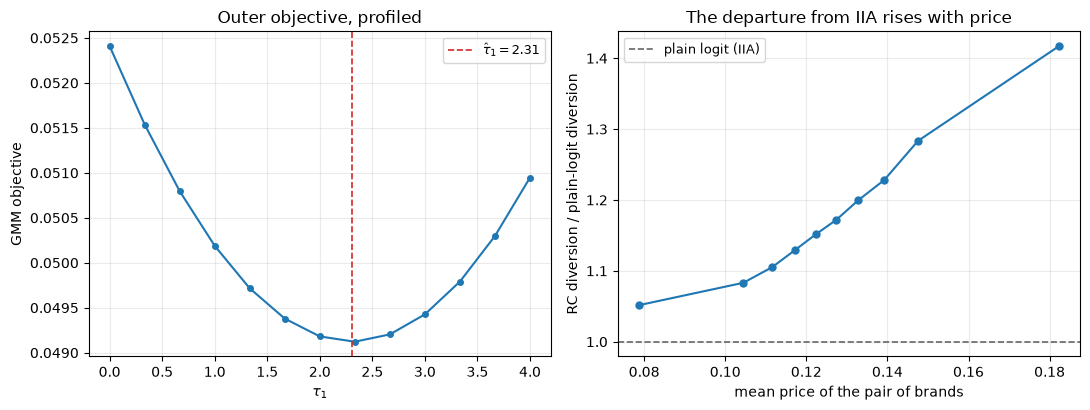

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

sig_grid = np.linspace(0.0, 4.0, 17 if not FAST_MODE else 13)
prof = [gmm_objective(np.array([sg, r2.x[1], r2.x[2]]), W_two) for sg in sig_grid]
ax[0].plot(sig_grid, prof, 'o-', color='C0', ms=4)
ax[0].axvline(r2.x[0], color='C3', ls='--', lw=1.2,
              label=rf'$\hat\tau_1={r2.x[0]:.2f}$')
ax[0].set_xlabel(r'$\tau_1$'); ax[0].set_ylabel('GMM objective')
ax[0].set_title('Outer objective, profiled')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.25)

pair_price = (price_src + price_dst) / 2
edges = np.quantile(pair_price, np.linspace(0, 1, 11))
ctr = 0.5 * (edges[:-1] + edges[1:])
means = [ratio[(pair_price >= a_) & (pair_price <= b_)].mean()
         for a_, b_ in zip(edges[:-1], edges[1:])]
ax[1].plot(ctr, means, 'o-', color='C0', ms=5)
ax[1].axhline(1.0, color='0.4', ls='--', lw=1.2, label='plain logit (IIA)')
ax[1].set_xlabel('mean price of the pair of brands')
ax[1].set_ylabel('RC diversion / plain-logit diversion')
ax[1].set_title('The departure from IIA rises with price')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.25)

plt.tight_layout(); plt.show()

*Left.* The GMM objective profiled in $\tau_1$, with the other two parameters at their estimates. A single well-defined interior minimum, which is what made the multi-start agreement in section 4 unsurprising. Note the vertical scale: the objective moves by about 7% across the whole range of $\tau_1$, and by far less than that within a neighbourhood of the optimum. That mild local curvature is exactly why the inner-loop tolerance has to be tight — an inner solve accurate to only $10^{-6}$ would inject noise of the same order as the signal the optimizer is trying to read.

*Right.* The ratio of RC-logit diversion to plain-logit diversion, averaged within deciles of the mean price of the pair, pooled over all markets and all ordered pairs. The dashed line at one is what IIA asserts. The relationship is monotone and economically large: among the cheapest cereals the two models nearly agree, while among the most expensive the plain logit understates diversion by around a third.

## Summing up

* **The inversion is what makes IV possible.** Berry's $U_y=\log\hat\pi_y-\log\hat\pi_0$ turns a nonlinear demand system into an equation that is linear in the unobserved quality, after which the endogeneity of price is an ordinary IV problem. Everything else in this notebook is machinery for doing the same thing when the inversion has no closed form.
* **Simulation recovery first.** On the book's synthetic data OLS returns a price coefficient of the wrong sign and IV recovers the true $-0.5$. An estimator that fails this test is not repaired by better data.
* **On Nevo's cereal data, brand dummies do most of the work.** The price coefficient moves from $-7.6$ to $-29$ when brand dummies enter, and only to $-30.2$ when the twenty instruments are added on top. The unobserved quality here is largely a persistent brand attribute; fixed effects absorb it, and the instruments correct the market-level remainder.
* **The estimator was checked against an independent implementation.** Internal checks — fixed point reached, moments matched, starts agreeing — cannot catch a mis-specified $\nu^{\tau}$; pyblp 1.2.0 on the same specification agrees on every parameter to within a fifth of a standard error, and independently reports $\tau_2$ as unidentified.
* **BLP's contraction is an IPFP/Sinkhorn half-step**, verified to machine precision as an identity between maps, not merely at the fixed point. Its convergence is therefore Franklin and Lorenz's Hilbert-metric result applied to the entropic transport problem of lecture 6 — the same $(u_i,\delta_j)$ dual pair that has appeared in every notebook of this series.
* **The economics: who buys the expensive cereals determines where their customers go.** Random coefficients move the price coefficient to about $-36$ and imply a mean own-price elasticity near $-3.7$ with no brand in the inelastic region. Pooled across every market and every pair, the substitution matrix differs from the IIA one by 19% in relative terms, and that departure is organized by **price level** — rising monotonically from $1.07$ to $1.33$ times the logit diversion across price quartiles. The mechanism is the estimated income–price interaction: premium brands are bought by the price-insensitive, whose customers switch to rivals rather than leaving the market. A merger analysis between two premium brands run on plain logit would understate diversion by about a third. (There is no sugar-similarity story in this specification, because $\tau_2$ was estimated at zero; exercise 1 restores that channel.)

## Exercises

**1. (Computation — the full Nevo specification.)** Extend $\tau$ to Nevo's own specification: random coefficients on the constant, price, sugar and mushy, interacted with income, income squared, age and the child dummy. Report the estimates and compare the implied own-price elasticities with the reduced specification used here. Which of the additional parameters change the substitution patterns, and which only change the fit?

**2. (Computation — inner-loop tolerance.)** Re-estimate with the contraction tolerance set to $10^{-4}$, $10^{-6}$, $10^{-8}$ and $10^{-13}$, from the same starting values. Report the estimated $\tau$ and the number of outer evaluations in each case. Relate what you find to the profile in the figure above and to the argument of Dubé, Fox and Su, and state the tolerance you would use in practice and why.

**3. (Proof — the contraction identity.)** Prove that the BLP contraction and the IPFP update coincide, by carrying out in general the substitution sketched in section 3. Then use Franklin and Lorenz's result to give a bound on the contraction modulus in terms of the spread of $\nu^{\tau}_{tiy}$, and check your bound against the observed factor printed in section 3.

**4. (Economics — a merger.)** Suppose the two brands with the highest diversion between them are proposed for merger. Using the estimated elasticity matrix and assuming Bertrand pricing with constant marginal costs, (i) back out the implied marginal costs from the pre-merger first-order conditions; (ii) compute the post-merger equilibrium prices for the merged brands; (iii) repeat the whole exercise under the plain logit estimates and compare the predicted price increases. Which model would a competition authority prefer, and on what evidence?

**5. (Economics — what the instruments assume.)** Nevo's instruments are prices of the same brand in other cities. State the exclusion restriction they require, and construct a plausible story under which it fails. Then, taking the story seriously, simulate data in which it fails and measure the resulting bias in $\hat\lambda_p$. Lecture 11 studies choice under capacity constraints; conjecture how a binding capacity constraint in one city would interact with this identification strategy.

---

### Run notes

`FAST_MODE = True` uses two starting values for the outer optimization and a 13-point profile; `False` uses three starts and 17 points. Every assertion holds in both modes.

The data are Nevo's simulated cereal data, read from `mec_datasets/demand_nevo/` with a fallback to the copy distributed with `pyblp`, which is the most convenient public mirror. The notebook itself uses numpy, scipy, pandas and matplotlib only.

Section 4 contains an **optional** external check against pyblp, behind a guarded import: it runs and asserts agreement when pyblp is installed, and prints a one-line notice when it is not, so the notebook executes either way. The relabelling of the agent draws it performs is necessary because pyblp matches nodes to the columns of $X_2$ in order, while this notebook uses Nevo's original node ordering.

Two departures from the book's listings. Listing `4-05`'s `lambda_gmm` reads its dependent variable from the enclosing scope rather than from its own first argument; the version here uses the argument. And listing `4-07` gives a full BLP implementation with analytic gradients and a supply side, in seventeen steps and with sparse-tensor operations that require the `sparse` package; that is beyond the scope of a lecture, and the demand-side estimator built here is the part that carries the ideas. The full replication, with a PyBLP comparison, lives in the companion notebook `rp01_blp`.

**Next:** lecture 8 leaves the static market. Dynamic discrete choice makes the systematic utility a continuation value, and the inversion of lecture 1 becomes a statement about the value function.